Writing countsT shape=(35635, 29065) chunks=(35635, 15065)



Minimum cell count (562) is lower than size factor multiplier (1000)



Calculating summary statistics



(RNA) feature stats block 1/2: read 2.0s (r2) compute 0.9s rss 2590 MiB



(RNA) feature stats block 2/2: read 1.1s (ram) compute 1.1s rss 1323 MiB



Calculating HVGs



500 genes marked as HVGs



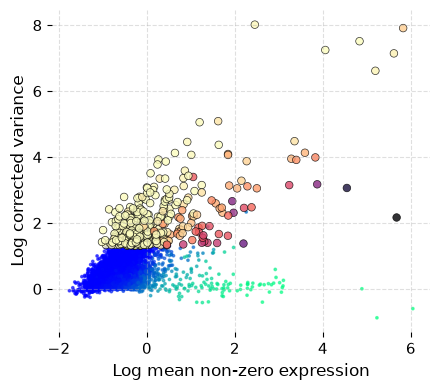

make_graph step 1/7: normalize expression matrix (computing)



make_graph step 1/7: normalize expression matrix finished in 3.9s (computing)



make_graph step 2/7: normalization statistics (computing)



make_graph step 2/7: normalization statistics finished in 0.1s (computing)



make_graph step 3/7: dimension reduction, ANN index, and kmeans (computing)



...

make_graph step 6/7: smooth KNN distances into graph finished in 9.1s (computing)



ANN recall: 99.93%



make_graph step 7/7: finalize graph metadata (computing)



make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)



make_graph finished in 16.5s (7/7 steps, 16.4s in logged steps)



In [1]:
import scarf

scarf.fetch_dataset("kang_15K_pbmc_rnaseq", save_path="scarf_datasets", as_zarr=True)
scarf.fetch_dataset(
    "kang_14K_ifnb-pbmc_rnaseq", save_path="scarf_datasets", as_zarr=True
)

ds_ctrl = scarf.DataStore("scarf_datasets/kang_15K_pbmc_rnaseq/data.zarr", nthreads=4)
ds_stim = scarf.DataStore(
    "scarf_datasets/kang_14K_ifnb-pbmc_rnaseq/data.zarr", nthreads=4
)

merged = "scarf_datasets/kang_merged_pbmc_rnaseq.zarr"
scarf.AssayMerge(
    zarr_path=merged,
    assays=[ds_ctrl.RNA, ds_stim.RNA],
    names=["ctrl", "stim"],
    merge_assay_name="RNA",
    overwrite=True,
).dump()

ds = scarf.DataStore(merged, nthreads=4)
ds.cells.insert(
    column_name="sample_id",
    values=[x.split("__")[0] for x in ds.cells.fetch_all("ids")],
    overwrite=True,
)
ds.cells.insert(
    column_name="imported_labels",
    values=list(ds_ctrl.cells.fetch_all("cluster_labels"))
    + list(ds_stim.cells.fetch_all("cluster_labels")),
    overwrite=True,
)
ds.mark_hvgs(min_cells=20, top_n=500)
ds.make_graph(feat_key="hvgs", k=11, dims=15, n_centroids=100)
ds.run_leiden_clustering(resolution=0.5)

In [2]:
lisi = ds.metric_lisi(label_colnames=["sample_id"])
lisi

Using the latest knn graph at location: RNA/normed__I__hvgs/reduction__pca__15__I/ann__l2__50__50__48__4466/knn__11



Perplexity 30 requires at least 90 neighbors, but the graph has 11. Using perplexity 3.66667.



Computing LISI for sample_id



[('sample_id',
  array([1.03323803, 1.10342121, 1.        , ..., 1.        , 1.        ,
         1.        ], shape=(29065,)))]

In [3]:
ds.metric_batch_mixing(label_colname="sample_id")

Using the knn graph at location: RNA/normed__I__hvgs/reduction__pca__15__I/ann__l2__50__50__48__4466/knn__11



Perplexity 30 requires at least 90 neighbors, but the graph has 11. Using perplexity 3.66667.



Computing LISI for sample_id



0.03743231862929488

In [4]:
ds.metric_silhouette(res_label="leiden_cluster")

Using the latest knn graph at location: RNA/normed__I__hvgs/reduction__pca__15__I/ann__l2__50__50__48__4466/knn__11 for assay: RNA



Loaded existing ANN stream from RNA/normed__I__hvgs/reduction__pca__15__I/ann__l2__50__50__48__4466



array([ 0.35142248,  0.5005044 ,  0.45794749,  0.5035922 , -0.04998804,
        0.1499605 , -0.0095266 ,  0.47621041, -0.0537269 ,  0.14107169,
        0.49794809,  0.45521678, -0.08805009,  0.60140825])

In [5]:
ds.metric_label_concordance(label_columns=["RNA_leiden_cluster", "imported_labels"])

0.00036094194402219536